# Steam Games Data Analysis & Recommendation System 

Introduction: The purpose of this project is to build a recommendation system for PC games using Steam data. We also visualize this data and answer several buisness questions such as:

    1. Which genres generate the most revenue?

    2. Games of which genres are played the most (by number of hours)?

    3. How well do positive ratings by users coorelate with the revenue generated by a game?

    4. How popular are games for which discounts are offerent as opposed to those for which none are offered?

The data we'll use is taken from Kaggle: https://www.kaggle.com/datasets/fronkongames/steam-games-dataset

This dataset is fairly large: 122,6211 rows (games/rows) and 39 attributes (columns). We choose to work with the csv file instead of json since the data is mostly tabular. There are several problems with the data and we will spend a fair bit of time making the data usable. In particular:

    1. We'll drop certain attributes that don't give us useful information: like URLs. There are some games with zero users! We'll drop these.

    2. A few attributes have no values for most rows: we'll have to drop these as well.

    3. Several column names don't correspond with the values in the rows. i.e., there is a mismatch of column name and what values they contain.

    4. There might be duplicate games (this is likely because some game publishers release different versions of a game in different countries.)

Let's begin by loading the data and exploring what it looks like.

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

In [45]:
df = pd.read_csv('C:/Python/Data Science Projects/Data/games.csv')

In [46]:
df.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,DiscountDLC count,About the game,Supported languages,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


In [6]:
df.shape

(122611, 39)

We observe that there are several issues with this dataset. 

1. The names of the first nine attrributes (columns) are incorrectly aligned. In particular, the attribute "DiscountDLC count" should be two separate attributes. 
2. While the attribute AppID can serve as a unique datapoint (row) identifier, we will reindex the rows using positive integers.
3. We'll get rid of attributes whose data contains URL. These attributes are not useful to us.
4. We will also get rid of those datapoints that do not contains useful information. 

In [7]:
df.columns

Index(['AppID', 'Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'DiscountDLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies'],
      dtype='str')

In [8]:
df.columns = ['Name', 'Release date', 'Estimated owners', 'Peak CCU',
       'Required age', 'Price', 'Discount', 'DLC count', 'About the game',
       'Supported languages', 'Full audio languages', 'Reviews',
       'Header image', 'Website', 'Support url', 'Support email', 'Windows',
       'Mac', 'Linux', 'Metacritic score', 'Metacritic url', 'User score',
       'Positive', 'Negative', 'Score rank', 'Achievements', 'Recommendations',
       'Notes', 'Average playtime forever', 'Average playtime two weeks',
       'Median playtime forever', 'Median playtime two weeks', 'Developers',
       'Publishers', 'Categories', 'Genres', 'Tags', 'Screenshots', 'Movies']

We replace the attribute "AppID" with a simple indexing column. 

In [9]:
df = df.reset_index(drop=True)
df.index = df.index + 1

In [10]:
df.dtypes

Name                              str
Release date                      str
Estimated owners                  str
Peak CCU                        int64
Required age                    int64
Price                         float64
Discount                        int64
DLC count                       int64
About the game                    str
Supported languages               str
Full audio languages              str
Reviews                           str
Header image                      str
Website                           str
Support url                       str
Support email                     str
Windows                          bool
Mac                              bool
Linux                            bool
Metacritic score                int64
Metacritic url                    str
User score                      int64
Positive                        int64
Negative                        int64
Score rank                    float64
Achievements                    int64
Recommendati

We wish to drop attributes that serve no use. To see what type of data each attribute contains, we check the head of ten attributes at a time and we demonstrate one example of this below. We notice that several attributes are strings that store URL.   

In [11]:
df.iloc[0:5, 29:39]

,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
1,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
2,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
3,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
4,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
5,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


We will drop those attributes whose entries are URL since this data is not useful to us. We also notice that the attribute "Movies" contains a lot of NaN entries. We find below that all entries are NaN and so we drop this attribute as will. 

In [12]:
print(df['Movies'].count())

0


Lastly, we note below that there are only 40 games that have non-zero "User score". We will also drop is statistically insignificant attribute. 

In [13]:
print((df['User score'] != 0).sum())

40


We now drop all columns we wish to at the same time and take a look at what our data now looks like.  

In [14]:
df = df.drop(columns = ['Header image', 'Website', 'Support url', 'Support email', 'Metacritic url', 
                   'User score', 'Screenshots', 'Movies']);

We now work on the rows and start by removing games that contain undesired elements. We do this performing a word search and then changing our dataframe to leave those games alone that do NOT contain these words. 

In [15]:
# Words we wish to search
words = 'extreme violence|intercourse|prostitution|pornography|pornographic|hentai'

# Search these words across relevant attributes
nope_words = (df['About the game'].str.contains(words, case=False, na=False)) | \
       (df['Reviews'].str.contains(words, case=False, na=False)) | \
       (df['Notes'].str.contains(words, case=False, na=False)) | \
       (df['Categories'].str.contains(words, case=False, na=False)) | \
       (df['Genres'].str.contains(words, case=False, na=False)) | \
       (df['Tags'].str.contains(words, case=False, na=False)) 
       
df = df[~nope_words]

In [16]:
df.shape

(119547, 31)

In [17]:
df.dtypes

Name                              str
Release date                      str
Estimated owners                  str
Peak CCU                        int64
Required age                    int64
Price                         float64
Discount                        int64
DLC count                       int64
About the game                    str
Supported languages               str
Full audio languages              str
Reviews                           str
Windows                          bool
Mac                              bool
Linux                            bool
Metacritic score                int64
Positive                        int64
Negative                        int64
Score rank                    float64
Achievements                    int64
Recommendations                 int64
Notes                             str
Average playtime forever        int64
Average playtime two weeks      int64
Median playtime forever         int64
Median playtime two weeks       int64
Developers  

In [18]:
df.head()

,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,Supported languages,...,Notes,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags
1,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,[],...,NaN,0,0,0,0,NaN,NaN,NaN,NaN,NaN
2,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",['English'],...,NaN,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute"
3,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...","['English', 'French', 'German', 'Russian']",...,NaN,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec..."
4,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",['Korean'],...,The game includes the following elements. 1. G...,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN
5,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,['English'],...,NaN,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN


Let's check if there are duplicate rows. Duplicate rows will have identical entires for each attribute. The pandas function drop_duplicates() will keep one copy while tossing out the other duplicate ones. 

In [19]:
unique_count = len(df.drop_duplicates())
print(f"There are {unique_count} unique rows.")

df = df.drop_duplicates()

There are 119540 unique rows.


## Revenue Estimation

We would like to get an estimate of revenue generated by each game. To do this, we define Estimated revenue = Estimated owners X Price. In doing so, we are making several assumptions:

1. Since "Price" is in USD, we are ignoring the fact that games are also bought by people outside the US using currencies different from the USD.
2. Many games go on discount a few times a year so the actual revenue generated is typically lower.
3. Steam takes a cut from the price a buyer pays for a game so the actual revenue a game developer generates is smaller. Similarly, several other "middle men" take their cut, for example, the game publisher, game promoters, etc.
4. There are "fremium" games
5. Lastly, the entries in the attribute "Price" are proabably recorded at the time this dataset was created and the typical price of a game may fluctuate over time.
   
Of course, this is far from an ideal estimate, but nonetheless, "Estimated revenue" will give us an indication of how a paid game has performed financially. We keep in mind that "Estimated revenue" will typically be a gross upper bound of the actual revenue generated by the game. 

In [20]:
df['Estimated owners'].unique()

<StringArray>
[                '0 - 0',             '0 - 20000',       '100000 - 200000',
      '500000 - 1000000',         '20000 - 50000',       '200000 - 500000',
        '50000 - 100000',     '2000000 - 5000000',   '10000000 - 20000000',
     '1000000 - 2000000',   '20000000 - 50000000',    '5000000 - 10000000',
 '100000000 - 200000000',  '50000000 - 100000000']
Length: 14, dtype: str

First note that "Estimated owners" is a string-type range. We will create a new attribute "Average owners" by converting a given range to an integer by taking the midpoint of each range. For example, the range 50,000 - 100,000 will be converted to the integer 75,000.  

In [21]:
# Split the 'Estimated owners' column into two temporary columns
owners_split = df['Estimated owners'].str.split('-', expand=True).astype(float)

# Calculate the average of the range
# owners_split[0] is the low end, owners_split[1] is the high end
df['Average owners'] = (owners_split[0] + owners_split[1]) / 2

# Multiply by Price to get Estimated revenue
df['Estimated revenue'] = df['Average owners'] * df['Price']

Let's reorder the games by "Estimated revenue" in descending to see if we recognize some of the games. This seems like a much better head for this dataset!

In [22]:
df = df.sort_values(by='Estimated revenue', ascending=False);
df.iloc[0:20, 0]

105322                          New World: Aeternum
44135                            Black Myth: Wukong
16828                                      Palworld
59355                               Baldur's Gate 3
114886                                   ELDEN RING
1424                           Monster Hunter Wilds
65251                                 HELLDIVERS™ 2
4108                                Path of Exile 2
103608                                   Last Epoch
262                               Battlefield™ 2042
100899                               Battlefield™ V
68901                                Cyberpunk 2077
5378                                           Rust
91415                              EA SPORTS FC™ 25
111008                              DARK SOULS™ III
58559     Sekiro™: Shadows Die Twice - GOTY Edition
5108                                   Satisfactory
75384                  Mount & Blade II: Bannerlord
21184                                 7 Days to Die
14154       

## Visualizing the most successful genres 

Let's look at the genres of the top 1% games by estimated revenue. We do this by creating a word bubble to visualize which genres appear most often for this top 1% category. This will give us an idea of which genres perform well financially. We start by looking at the data contained in the "Genres" attribute more closely.

In [24]:
df.shape

(119540, 33)

In [32]:
df.iloc[0:5, 29:30]

,Genres
105322,"Action,Adventure,Massively Multiplayer,RPG"
44135,"Action,Adventure,RPG"
16828,"Action,Adventure,Indie,RPG,Early Access"
59355,"Adventure,RPG,Strategy"
114886,"Action,RPG"


Let's create a new dataframe (called top_1_percent) that contains the top 1% of our main dataframe. Then we'll first look at all the genres of the top 1% of the games. 

In [33]:
top_1_percent = df.head(int(len(df) * 0.01))

all_genres = []

for entry in top_1_percent["Genres"].dropna():
    genres = [g.strip() for g in entry.split(",")]
    all_genres.extend(genres)

unique_genres = sorted(set(all_genres))
print(unique_genres)

['Action', 'Adventure', 'Animation & Modeling', 'Audio Production', 'Casual', 'Design & Illustration', 'Early Access', 'Education', 'Free To Play', 'Game Development', 'Indie', 'Massively Multiplayer', 'Photo Editing', 'RPG', 'Racing', 'Simulation', 'Software Training', 'Sports', 'Strategy', 'Utilities', 'Video Production', 'Web Publishing']


Now we move on to create the Word Cloud.

In [36]:
from collections import Counter
import ast
import matplotlib.patches as mpatches
import numpy as np
from wordcloud import WordCloud

In [37]:
genre_counts = Counter(all_genres)

In [38]:
wc = WordCloud(
    width=1200,
    height=800,
    background_color="white",
    colormap="tab10",       # a colormap with distinct colors per genre
    max_words=50            # limit to top 50 genres if there are many
)

wc.generate_from_frequencies(genre_counts)

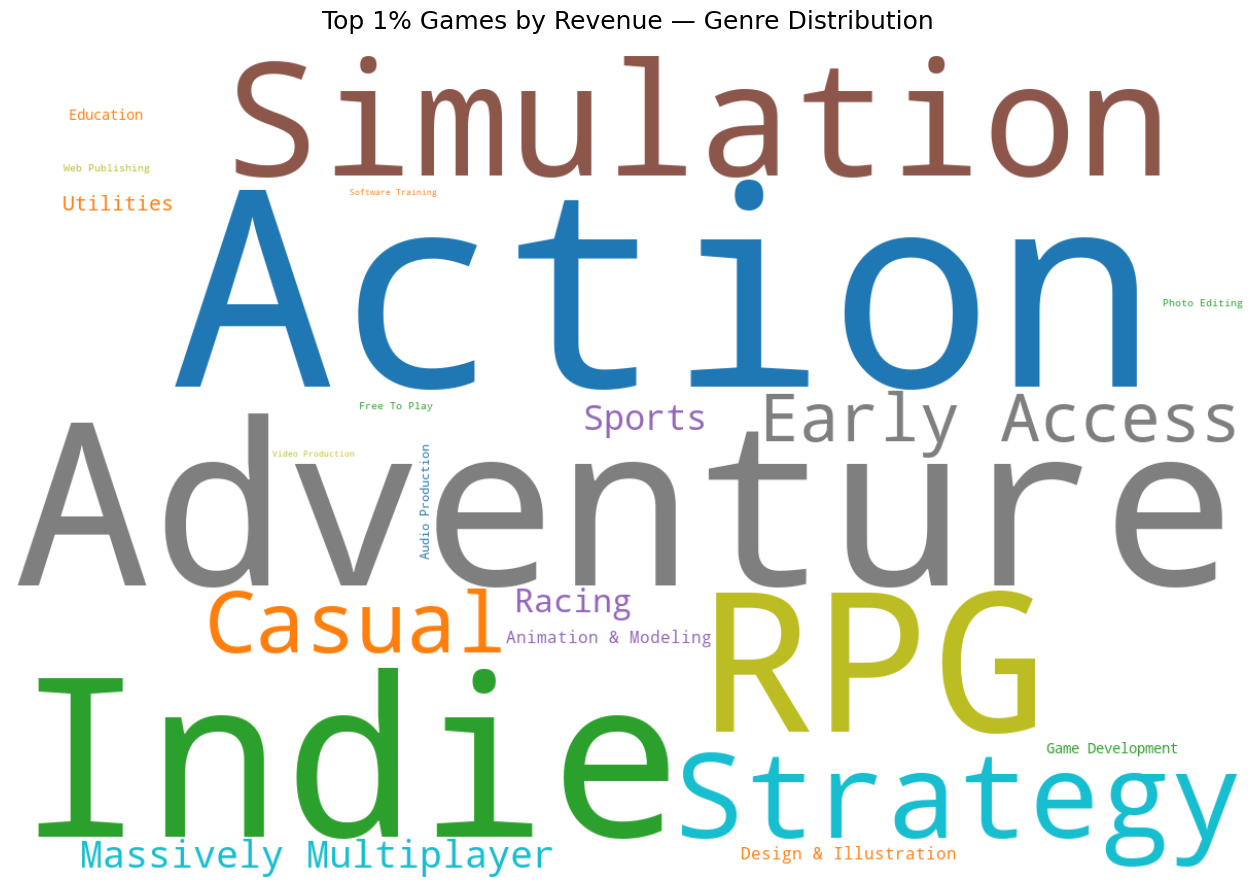

In [41]:
plt.figure(figsize=(14, 9))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Top 1% Games by Revenue — Genre Distribution", fontsize=18, pad=20)
plt.tight_layout()
plt.show()

This is a nice visual resprentation genres most successful by revenue. However, to be more analytically rigorous, let's use a bar chart to represent the game data - since our data ("Genres") is of categorical type, a bar chart is more approproate than a histogram.   

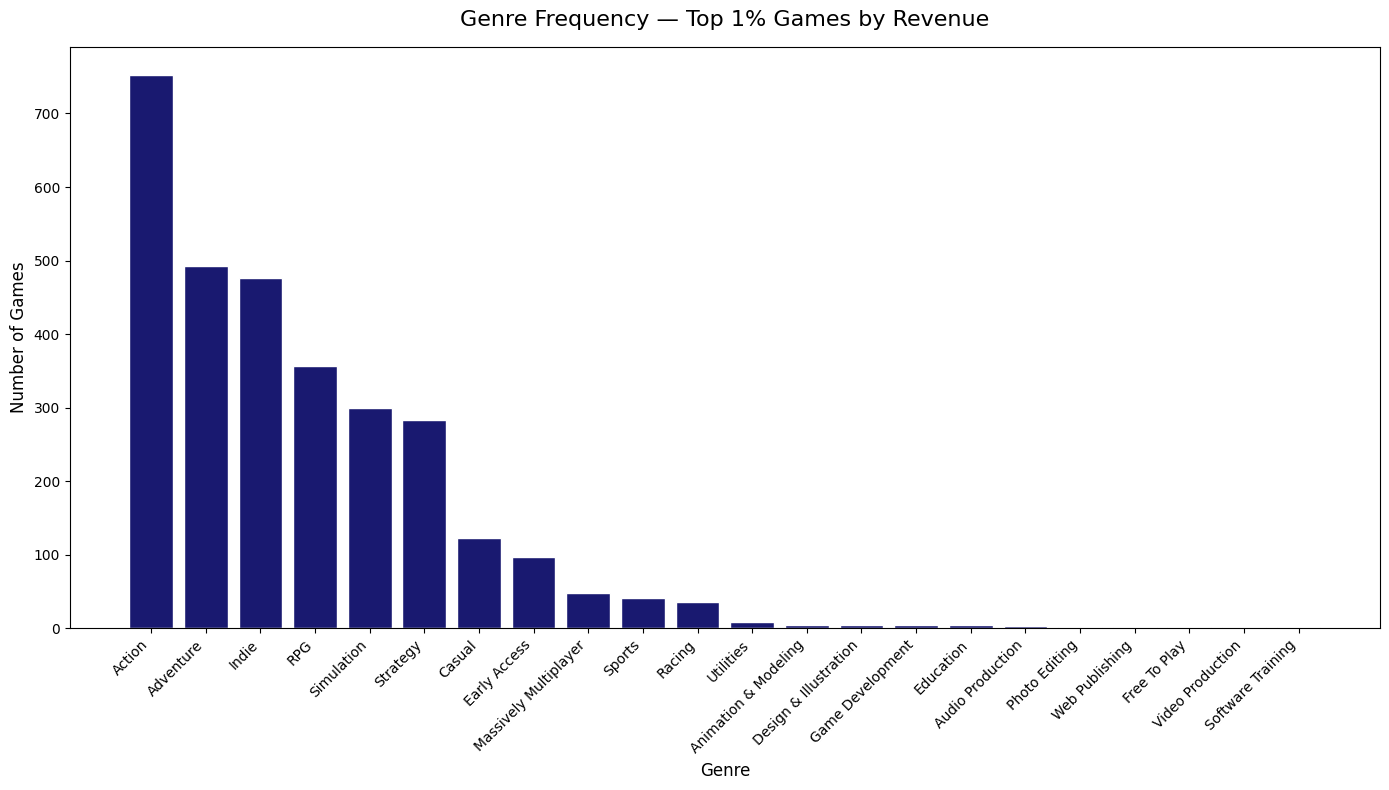

In [44]:
# Count already done from before, just convert to a sorted DataFrame for plotting
genre_df = pd.DataFrame(genre_counts.most_common(), columns=["Genre", "Count"])

# Plot
plt.figure(figsize=(14, 8))
plt.bar(genre_df["Genre"], genre_df["Count"], color="midnightblue", edgecolor="white")

plt.title("Genre Frequency — Top 1% Games by Revenue", fontsize=16, pad=15)
plt.xlabel("Genre", fontsize=12)
plt.ylabel("Number of Games", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.tight_layout()
plt.show()

This is excellent! We keep in mind that genres are not mutualy exclusive. A single game typically has multiple genres. Let's draw some elementary conclusions. 

1. Nearly 750 games out of 1195 games contain the Genre "Action".
2. The top 1% of the games don't contain many games with the genres "Sports" or "Racing". This may signal an opportunity (and a need) to make these games more popular.
3. About 100 games are "Early Access". These are games that are made available to purchase and play before their development is complete. That's about 8.3% of the top 1% of the games. 

However, note that the above distribution is not an accurate description of the success of a genre. The reason is that there are typically far more "Action" games than "Racing" games so it makes sense that the "Action" tag appears more often in the distribution. Therefore, we'll take the number of games with the tag "Action" and 